In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 0.设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False # 解决负号显示问题

# 设置整体风格
sns.set_theme(style="whitegrid", font='SimHei')
# 设置图表的背景主题(\darkgrid\ticks)    设置图表中文字的默认字体

tips = sns.load_dataset("tips")

数据可视化时不需要进行独热编码，在应用ML模型时再编码

In [ ]:
#手动控制ticks

# 设置 X 轴的刻度位置为 0, 1, 2, 3
axes[0, 1].set_xticks([0, 1, 2, 3])

# 设置 X 轴的刻度标签为自定义名字
axes[0, 1].set_xticklabels(['A', 'B', 'C', 'D'])

In [ ]:
# 颜色

Color 所有元素都使用单一颜色
Palette(调色板) 一组离散颜色的列表，为每个类别分配一个不同的颜色 'colorblind'
Cmap (Colormap / 颜色映射) 一个连续的渐变色谱，将数值的大小映射到颜色的深浅上'viridis''coolwarm'


In [ ]:
# 创建子图布局

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
# 创建一个“画布（fig）”和“轴数组（axes）”

sns.scatterplot(data=anscombe[anscombe['dataset']=='III'], x='x', y='y', ax=axes[1, 0])
sns.scatterplot(data=anscombe[anscombe['dataset']=='IV'], x='x', y='y', ax=axes[1, 1])

C:\Users\under\AppData\Local\Temp\ipykernel_50992\4263935360.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Group', y='Score',


<Axes: xlabel='Group', ylabel='Score'>

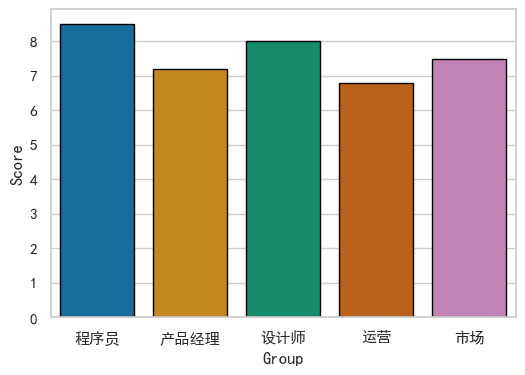

In [13]:
data = {
    'Group': ['程序员', '产品经理', '设计师', '运营', '市场'],
    'Score': [8.5, 7.2, 8.0, 6.8, 7.5]
}
df = pd.DataFrame(data)
                  
plt.figure(figsize=(6, 4))
sns.barplot(data=df, x='Group', y='Score', 
            palette='colorblind',  # 使用自定义列表
            edgecolor='black',       # 给柱状图加黑色细边框，学术风必备
            linewidth=1)


In [ ]:
# 1.计数图 看“选哪个的人多”

# 假设 'job' 列是职业
sns.countplot(data=clean_df, x='job', palette='viridis')
plt.title('用户职业分布')
plt.xticks(rotation=45) # 如果文字太挤，旋转45度
plt.show()

# | 职业 (job) |
# | :--- |
# | 程序员 |
# | 程序员 |
# | 教师 |

In [ ]:
# 2. 直方图 + 密度图 (Histplot) 看“数值怎么分布”

# kde=True 会画出一条平滑的曲线，代表概率密度
sns.histplot(data=clean_df, x='age', kde=True, rug=True, color='skyblue')
plt.title('用户年龄分布图')
plt.show()



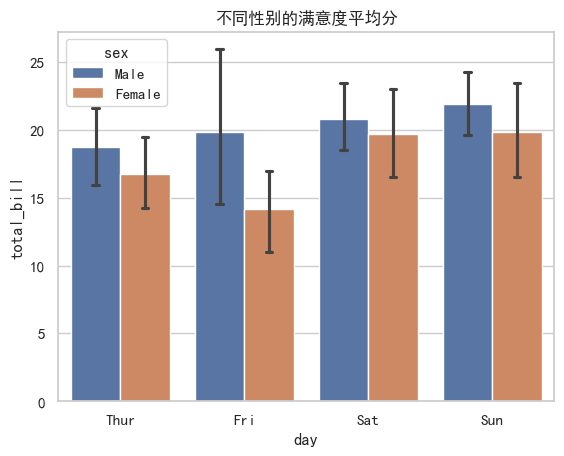

In [ ]:
# 3. 条形图 (Bar Plot)：看不同分组下，某个数值指标的表现。

# Seaborn 会自动帮你计算平均值，并画出误差棒（置信区间）
sns.barplot(data=tips, x='day', y='total_bill',hue='sex',errorbar='ci',capsize=0.1)# 给误差线加上横帽,更专业
# errorbar='ci'[默认]/'sd'/None， estimator=np.sum 计算总和而非均值
plt.title('不同性别的满意度平均分')
plt.show()

# | 分组 (Group) | 分数 (Score) |
# | :--- | :--- |
# | A组 | 80 |
# | A组 | 90 |
# | B组 | 70 |

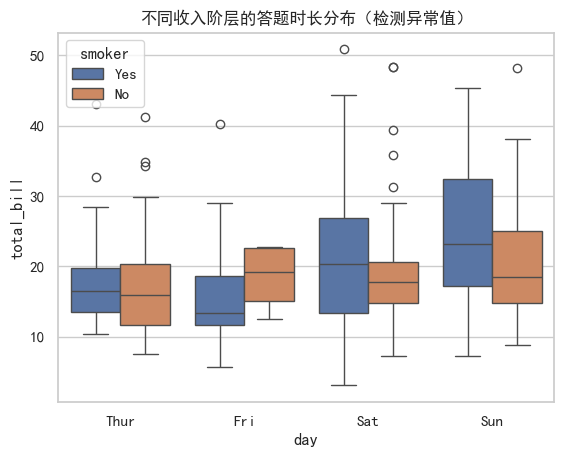

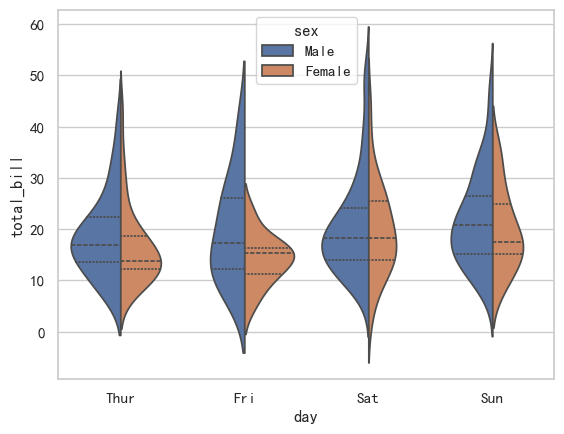

<Axes: xlabel='day', ylabel='total_bill'>

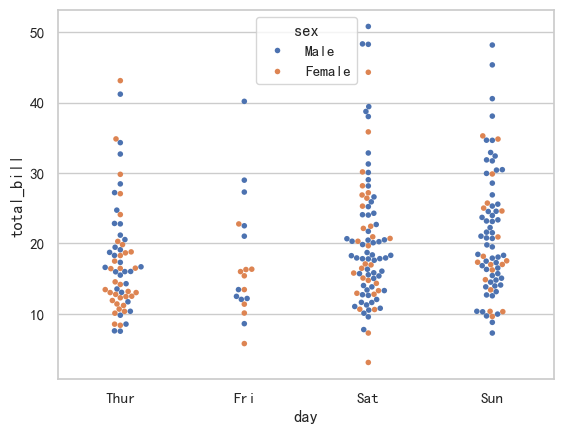

In [47]:
# 4. 箱线图 (Box Plot)：看“数据的极端情况”

sns.boxplot(data=tips, x='day', y='total_bill',hue='smoker' )
plt.title('不同收入阶层的答题时长分布（检测异常值）')
plt.show()

#4.1. 小提琴图
sns.violinplot(data=tips, x='day', y='total_bill', hue='sex', split=True, inner='quart')
# inner:'quart'：画出四分位线;'box'：在中间画一个迷你箱线图
# split: True 使用hue时，小提琴合并成一个（一边一组）
plt.show()

#4.2 蜂群图（叠加在箱线图或小提琴图之上）
sns.swarmplot(data=tips, x="day", y="total_bill", hue="sex", size=4)

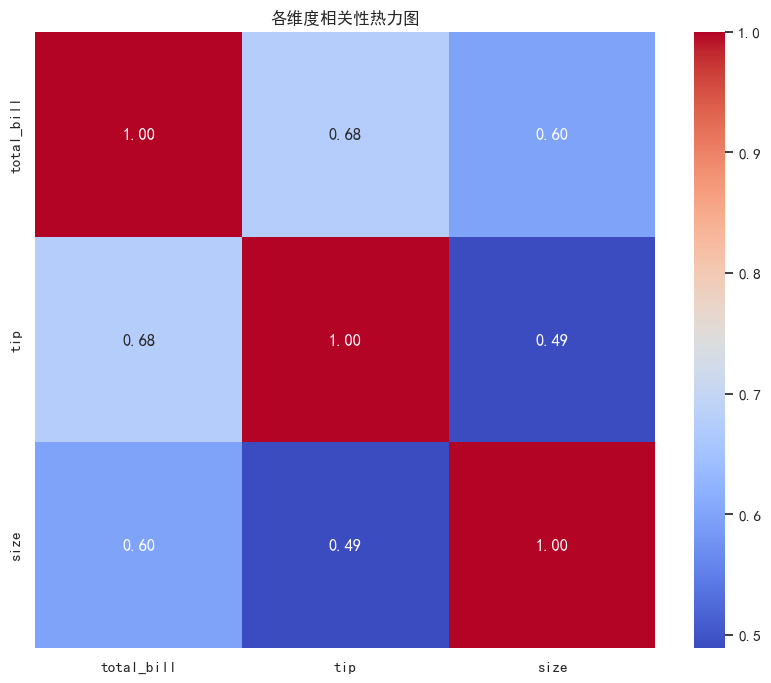

In [52]:
# 5. 热力图 (Heatmap)：看“谁和谁有关联”

plt.figure(figsize=(10, 8))
# 计算相关系数
corr = tips.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
# annot=True 会在格子里写数字，cmap 是配色,cbar是否显示右侧的颜色条（Colorbar），默认为 True
plt.title('各维度相关性热力图')
plt.show()

# df.corr(numeric_only=True)  只能计算数值列之间的线性关系
# 1. 定序数据（最适合热力图）   “满意”编为 5，“不满意”编为 1
# 2. 二分类数据     性别（男/女）、是否（是/否）
# 3. 无序分类数据（最难处理）   独热编码。热力图会多出 Job_程序员, Job_医生 等列。
# 如果 Job_程序员 与 满意度 的格子是红色的，说明程序员群体更倾向于给高分

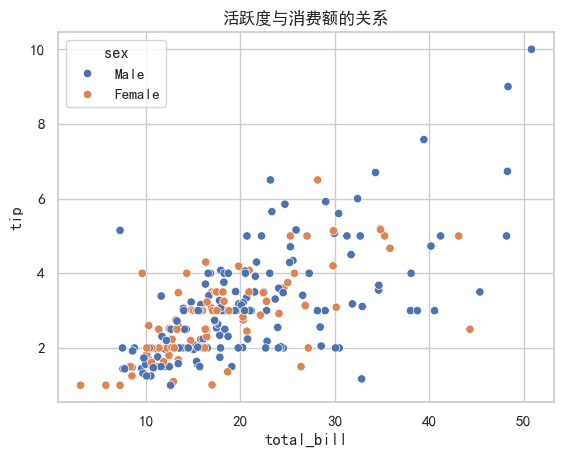

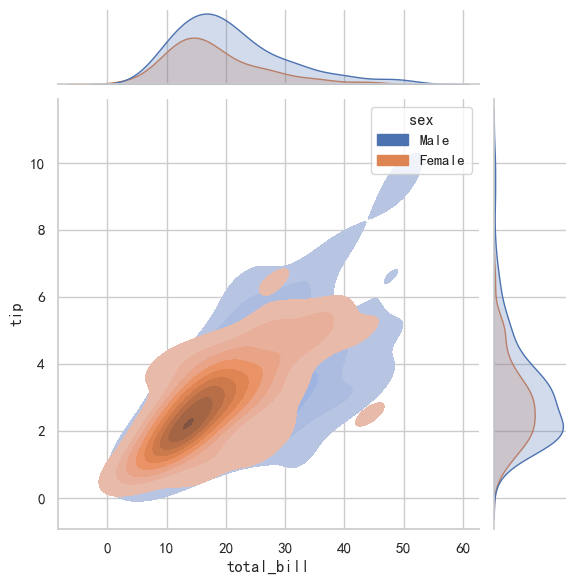

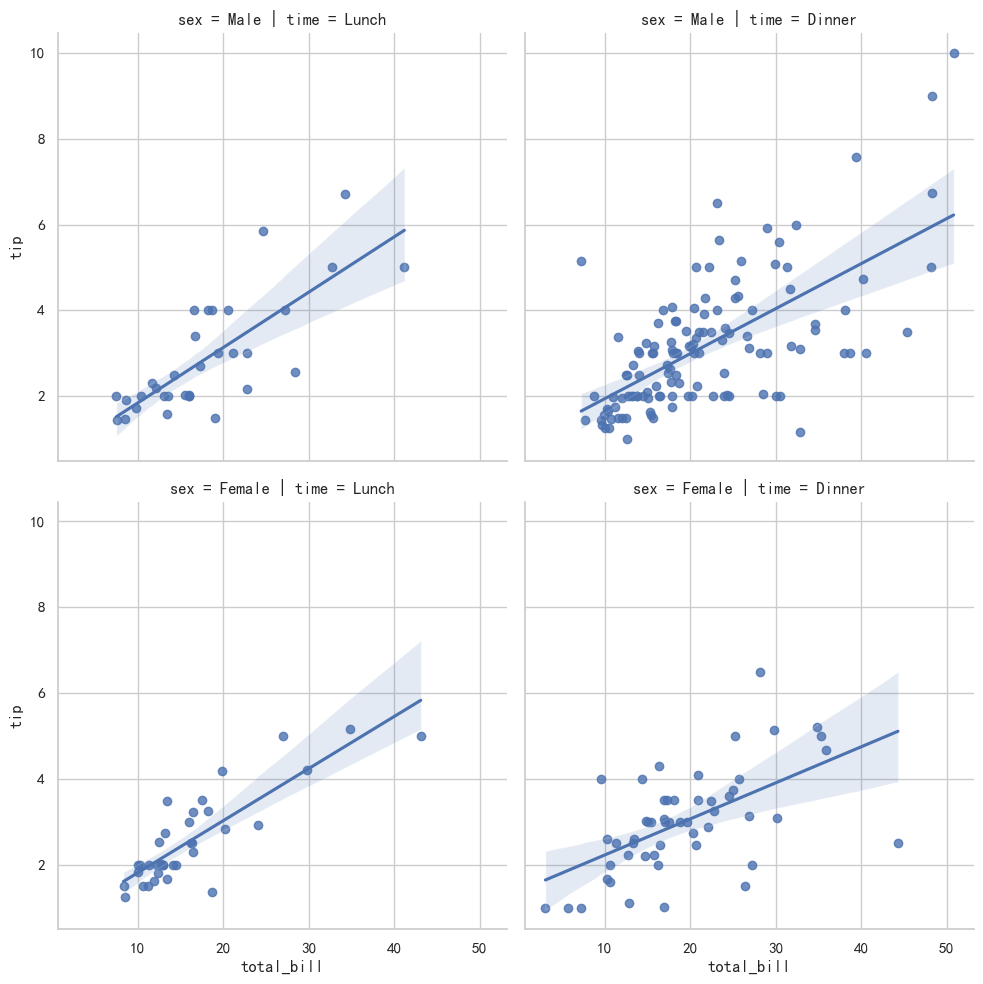

In [ ]:
# 6. 散点图 (Scatter Plot)：看“趋势”

sns.scatterplot(data=tips, x='total_bill', y='tip', hue='sex')
plt.title('活跃度与消费额的关系')
plt.show()

# 6.1 联合分布图 sns.jointplot(x=, y=, data=, hue=, kind="reg"/"hex"/"kde"/"resid") 同时展示联合分布（散点图）和边际分布（分布图）
# kind带回归线散点图/蜂巢图/二维kde图/残差图
sns.jointplot(data=tips, x="total_bill", y="tip", kind="kde",hue='sex',fill=True)

# 6.2 线性模型图
# 使用 col 和 row 实现多面板分面
sns.lmplot(data=tips, x="total_bill", y="tip", col="time", row="sex")



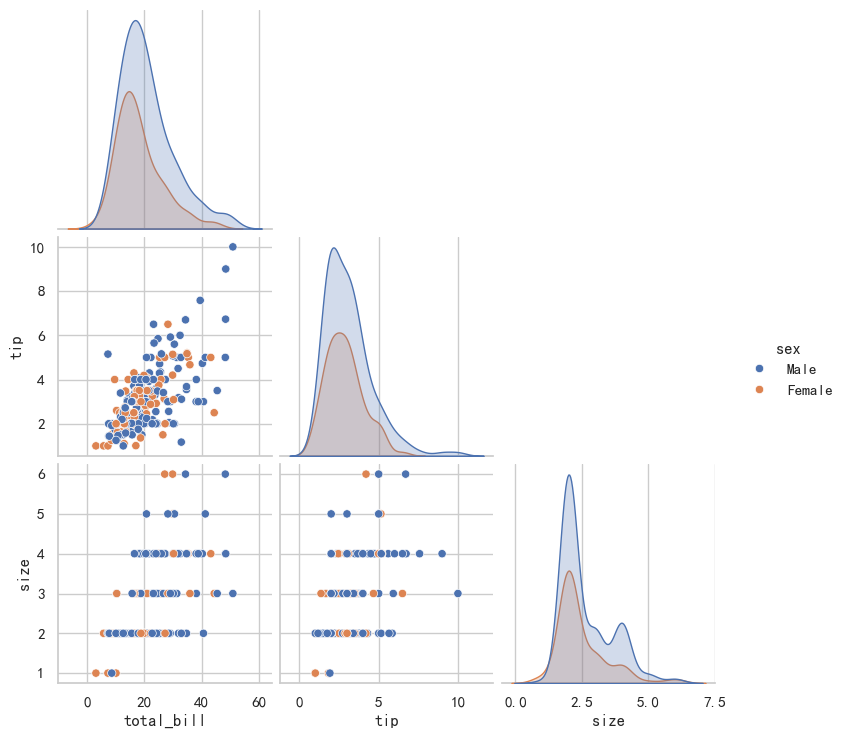

In [ ]:
# 7. 变量矩阵图 (变量矩阵图)

sns.pairplot(tips, hue='sex',corner=True) # 一次性看清所有维度的相互关系
# corner=True 忽略重复的对称部分

In [ ]:
# 更多额外设置
